In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

In [4]:
import os

os.listdir()

['.config', 'Advertising.csv', 'archive.zip', 'sample_data']

In [6]:
import pandas as pd

df = pd.read_csv("Advertising.csv")

In [ ]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [ ]:
df = df.drop("Unnamed: 0", axis=1)

In [ ]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
print("Average Sales:", df["Sales"].mean())

Average Sales: 14.0225


In [9]:
print("Highest Sales:", df["Sales"].max())

Highest Sales: 27.0


In [10]:
print("Lowest Sales:", df["Sales"].min())

Lowest Sales: 1.6


In [11]:
df.corr(numeric_only=True)

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

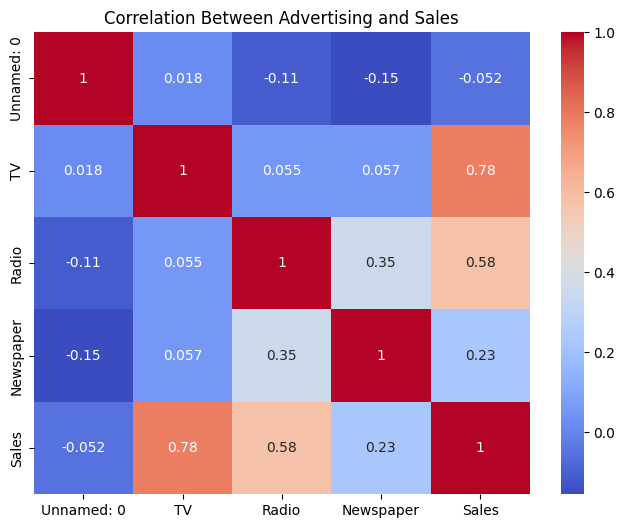

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Advertising and Sales")

plt.show()

In [15]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [16]:
print(df.columns.tolist())

['TV', 'Radio', 'Newspaper', 'Sales']


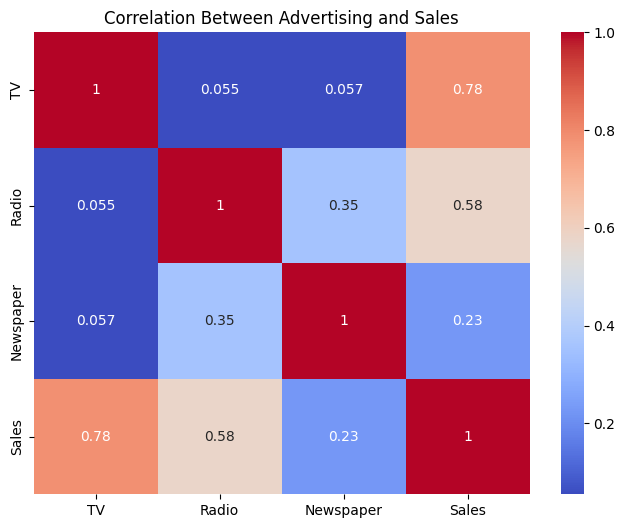

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Advertising and Sales")

plt.show()

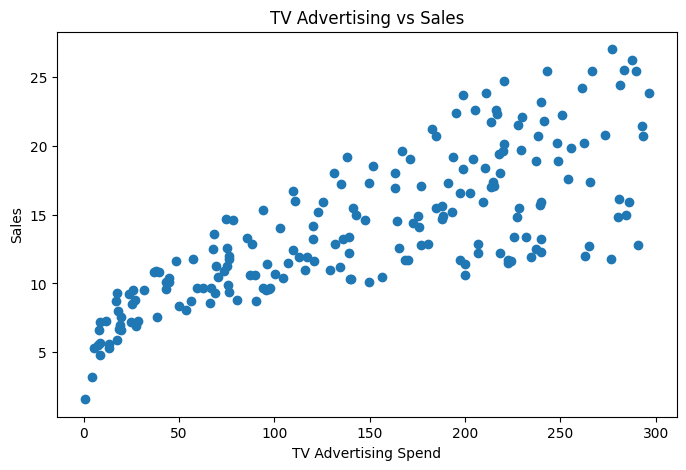

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df["TV"], df["Sales"])

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

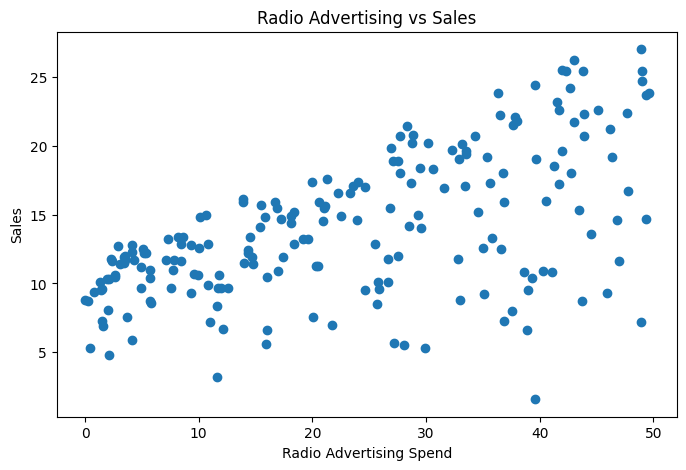

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(df["Radio"], df["Sales"])

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

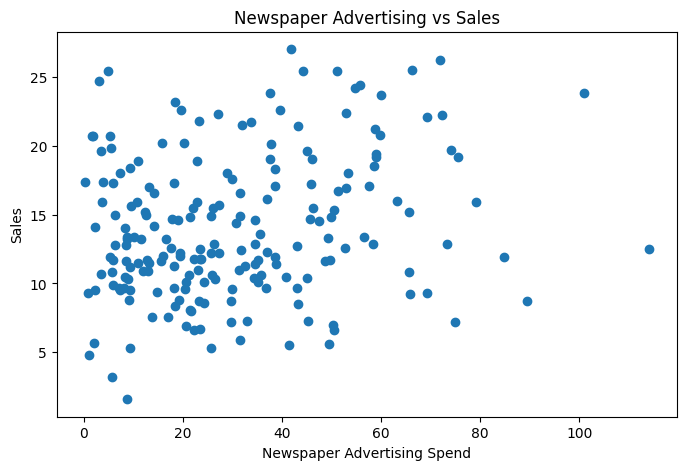

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df["Newspaper"], df["Sales"])

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

In [21]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [25]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.4607567168117603
Mean Squared Error (MSE): 3.1740973539761033
Root Mean Squared Error (RMSE): 1.78159966153345
R² Score: 0.899438024100912


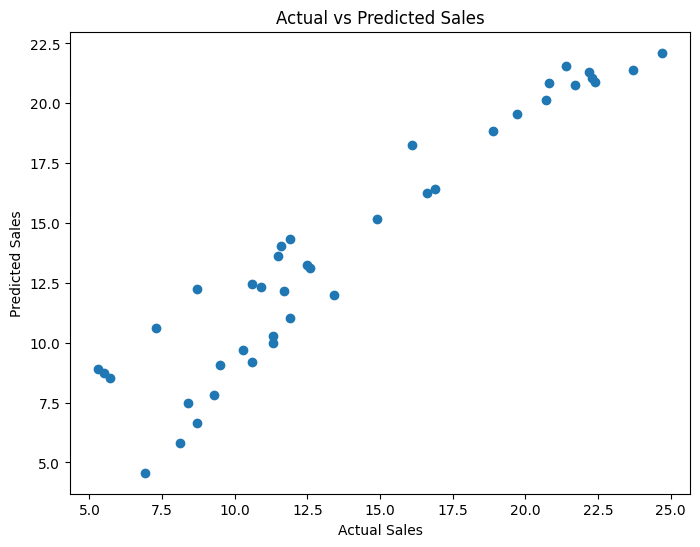

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

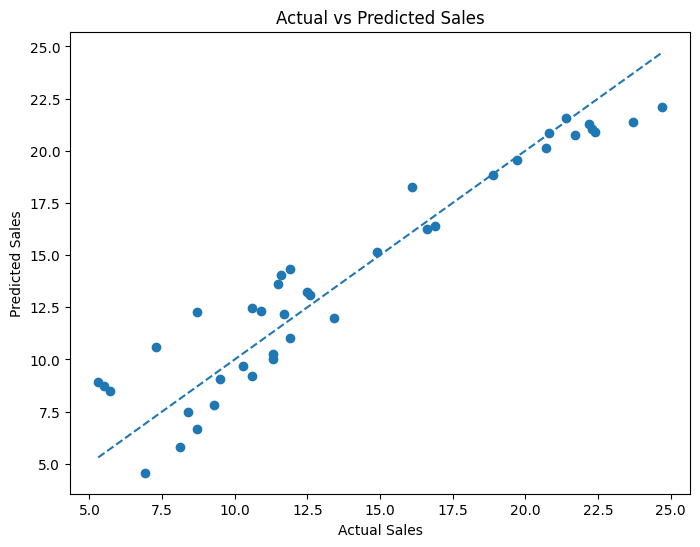

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [32]:
coefficients = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Advertising Channel,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


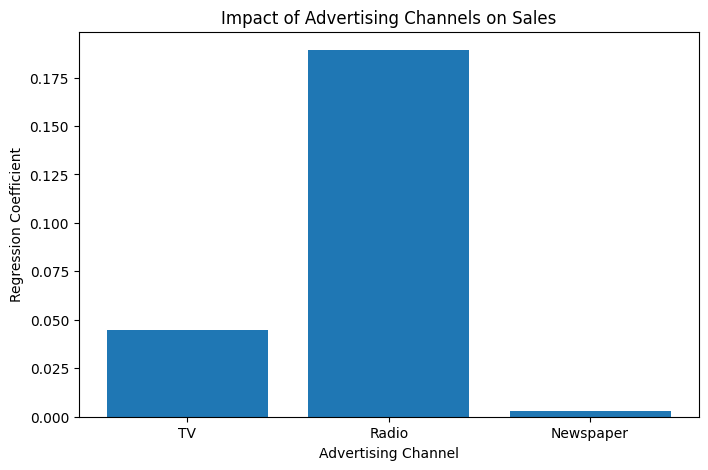

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    coefficients["Advertising Channel"],
    coefficients["Coefficient"]
)

plt.title("Impact of Advertising Channels on Sales")
plt.xlabel("Advertising Channel")
plt.ylabel("Regression Coefficient")

plt.show()

In [34]:
new_advertising = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_advertising)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 15.419568872288718


In [35]:
scenarios = pd.DataFrame({
    "TV": [100, 150, 200],
    "Radio": [20, 30, 40],
    "Newspaper": [10, 20, 30]
})

scenarios["Predicted Sales"] = model.predict(
    scenarios[["TV", "Radio", "Newspaper"]]
)

scenarios

,TV,Radio,Newspaper,Predicted Sales
0,100,20,10,11.263531
1,150,30,20,15.419569
2,200,40,30,19.575606


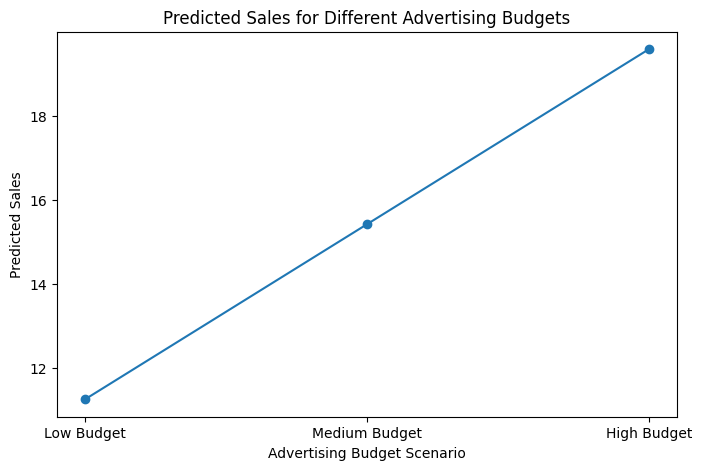

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(scenarios) + 1),
    scenarios["Predicted Sales"],
    marker="o"
)

plt.xticks(
    range(1, len(scenarios) + 1),
    ["Low Budget", "Medium Budget", "High Budget"]
)

plt.title("Predicted Sales for Different Advertising Budgets")
plt.xlabel("Advertising Budget Scenario")
plt.ylabel("Predicted Sales")

plt.show()

In [37]:
df.to_csv("Cleaned_Advertising_Data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
